### Imports

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt


### Load datasets from data directory

In [7]:
import os
import pandas as pd

def load_all_csvs():
    """
    Walks up directories until 'data' folder is found,
    loads all CSV files inside it, and creates DataFrames
    named '<filename>_df' in the global namespace.
    """
    current = os.getcwd()
    while not os.path.exists(os.path.join(current, "data")):
        current = os.path.dirname(current)

    data_dir = os.path.join(current, "data")

    print(f"Starting to load CSV files from: {data_dir}")

    for file in os.listdir(data_dir):
        if file.endswith(".csv"):
            file_path = os.path.join(data_dir, file)
            var_name = os.path.splitext(file)[0] + "_df"
            globals()[var_name] = pd.read_csv(file_path)
            print(f"Loaded DataFrame: {var_name}")

    print("Completed loading all CSV files.")

load_all_csvs()


Starting to load CSV files from: C:\Users\abeku\OneDrive\Desktop\PG Diploma\week-8\week-8\monday\data
Loaded DataFrame: olist_customers_dataset_df
Loaded DataFrame: olist_geolocation_dataset_df
Loaded DataFrame: olist_orders_dataset_df
Loaded DataFrame: olist_order_items_dataset_df
Loaded DataFrame: olist_order_payments_dataset_df
Loaded DataFrame: olist_order_reviews_dataset_df
Loaded DataFrame: olist_products_dataset_df
Loaded DataFrame: olist_sellers_dataset_df
Loaded DataFrame: product_category_name_translation_df
Loaded DataFrame: sensor_df
Completed loading all CSV files.


### create orders dataframe

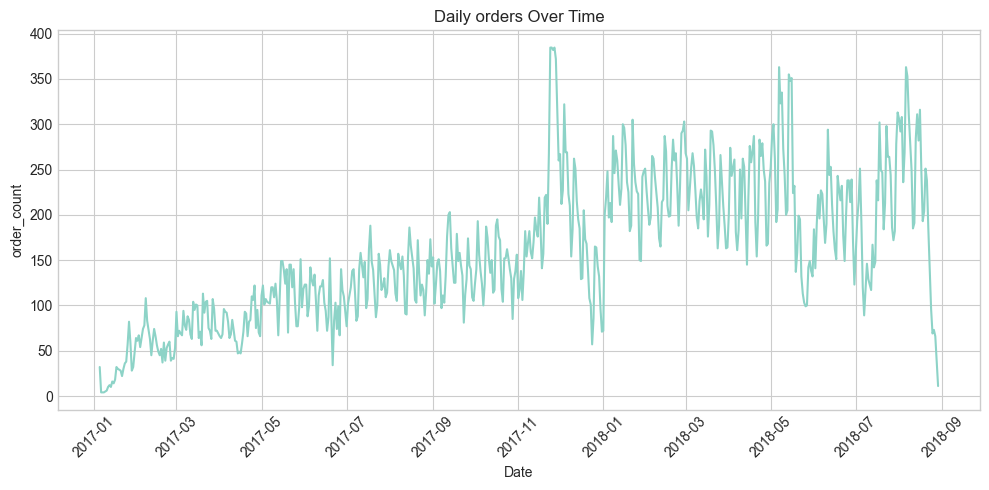

In [43]:
def create_orders_df():
    olist_orders_dataset_df['order_purchase_timestamp'] = pd.to_datetime(
        olist_orders_dataset_df['order_purchase_timestamp']
    )

    delivered = olist_orders_dataset_df[
        olist_orders_dataset_df['order_status'] == 'delivered'
    ].copy()

    delivered['date'] = delivered['order_purchase_timestamp'].dt.date

    pay_agg = (
        olist_order_payments_dataset_df
        .groupby('order_id')['payment_value']
        .sum()
        .reset_index()
    )

    delivered = delivered.merge(pay_agg, on='order_id', how='left')

    daily = delivered.groupby('date').agg(
        order_count=('order_id', 'nunique'),
        revenue=('payment_value', 'sum')
    ).reset_index()

    daily['date'] = pd.to_datetime(daily['date'])
    daily = daily.sort_values('date').reset_index(drop=True)

    # Focus period
    daily = daily[
        (daily['date'] >= '2017-01-01') &
        (daily['date'] <= '2018-08-31')
    ]

    # Fill missing dates
    idx = pd.date_range(daily['date'].min(), daily['date'].max(), freq='D')
    daily = daily.set_index('date').reindex(idx)
    daily.index.name = 'date'

    daily['order_count'] = daily['order_count'].fillna(0).astype(int)
    daily['revenue'] = daily['revenue'].fillna(0)

    daily = daily.reset_index()
    def cap_outliers(series):
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        return series.clip(lower=lower, upper=upper)

    daily['order_count'] = cap_outliers(daily['order_count'])
    daily['revenue'] = cap_outliers(daily['revenue'])

    return daily
orders_ts=create_orders_df()
plt.figure(figsize=(10, 5))
plt.plot(orders_ts['date'], orders_ts['order_count'])

plt.xlabel('Date')
plt.ylabel('order_count')
plt.title('Daily orders Over Time')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
display(orders_ts.head())

print(f"Loaded {len(orders_ts)} daily records")
print(f"Date range: {orders_ts['date'].min().date()} to {orders_ts['date'].max().date()}")
print(f"\nBasic stats:")
print(orders_ts['order_count'].describe().round(2))
print(f"\nMissing values: {orders_ts.isnull().sum().sum()}")

,date,order_count,revenue
0,2017-01-05,32.0,707.27
1,2017-01-06,4.0,988.28
2,2017-01-07,4.0,1447.99
3,2017-01-08,4.0,507.85
4,2017-01-09,5.0,774.51


Loaded 602 daily records
Date range: 2017-01-05 to 2018-08-29

Basic stats:
count    602.00
mean     158.37
std       78.79
min        4.00
25%      100.25
50%      148.00
75%      214.00
max      384.62
Name: order_count, dtype: float64

Missing values: 0


### Test stationarity

In [40]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(orders_ts['order_count'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


ADF Statistic: -2.997581612151705
p-value: 0.035120865324737065
Critical Values:
   1%: -3.4415393130846725
   5%: -2.866476335860869
   10%: -2.5693989358590006


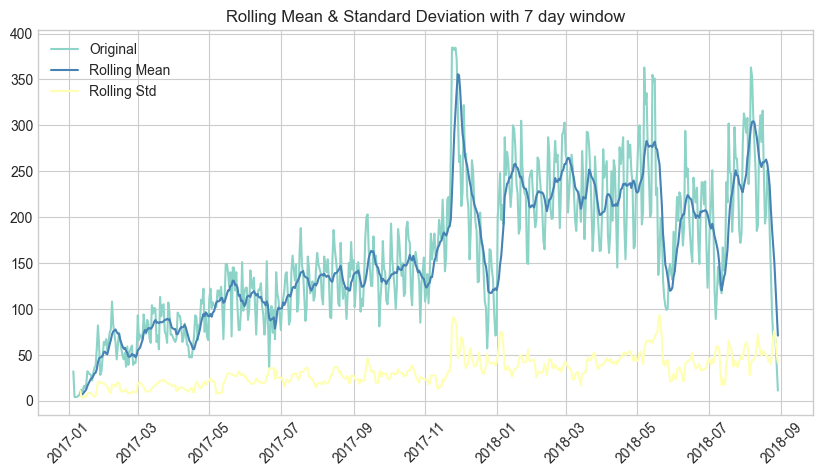

In [46]:
rolling_mean = orders_ts['order_count'].rolling(window=7).mean()
rolling_std = orders_ts['order_count'].rolling(window=7).std()
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10,5))
plt.plot(orders_ts['date'], orders_ts['order_count'], label='Original')
plt.plot(orders_ts['date'], rolling_mean, label='Rolling Mean',color='steelblue')
plt.plot(orders_ts['date'], rolling_std, label='Rolling Std')

plt.legend()
plt.title('Rolling Mean & Standard Deviation with 7 day window')
plt.xticks(rotation=45)
plt.show()

p value <.05 indicating stationarity but the statistical measures are not constant